In [ ]:
# Importing necessary liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

In [ ]:
# Loading dataset
anime = pd.read_csv('anime.csv')

In [3]:
# Basic info
anime.info()
anime.head()
print(anime.shape)

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB
(12294, 7)


In [4]:
# Missing values treatment
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [5]:
# Basic statistics
anime.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


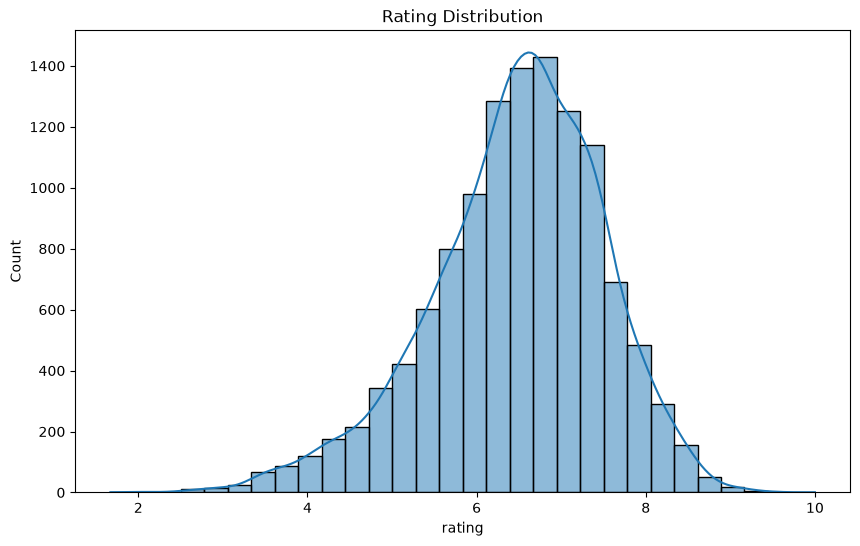

In [6]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(anime['rating'].dropna(), bins=30, kde=True)
plt.title("Rating Distribution")
plt.show()

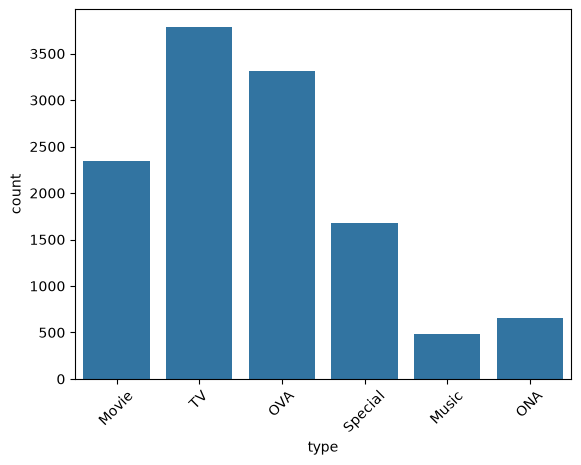

In [7]:
sns.countplot(x='type', data=anime)
plt.xticks(rotation=45)
plt.show()

In [8]:
# Data cleaning
anime = anime[['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']]

In [9]:
# Handling missing values
anime['genre'] = anime['genre'].fillna('')
anime['type'] = anime['type'].fillna('Unknown')
anime['rating'] = anime['rating'].fillna(anime['rating'].mean())

# Dropping duplicates
anime.drop_duplicates(subset='name', inplace=True)

In [10]:
# Feature engineering

anime['features'] = anime['genre'] + ' ' + anime['type'] + ' ' + anime['episodes'].astype(str) + ' ' + anime['rating'].astype(str)

In [13]:
# TFIDF Vectorization

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(anime['features'])
print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (12292, 243)


In [14]:
# Cosine Similarity Calculation

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Similarity Matrix Shape:", cosine_sim.shape)

Similarity Matrix Shape: (12292, 12292)


In [16]:
# Index Mapping

indices = pd.Series(anime.index, index=anime['name']).drop_duplicates()

In [19]:
# Recommendation Function

def recommend_anime(title, cosine_sim=cosine_sim):
    if title not in indices:
        return "Anime not found in the dataset."
    
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    # Similarity Scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # TOp 10 similar
    sim_scores = sim_scores[1:11]

    anime_indices = [i[0] for i in sim_scores]

    return anime['name'].iloc[anime_indices]

In [20]:
# test recommendation function
print(recommend_anime("Naruto"))

7867                                      Iron Virgin Jun
1573    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
4067                       Ikkitousen: Extravaganza Epoch
2458                 Naruto Shippuuden: Sunny Side Battle
1930                                    Dragon Ball Super
2997    Naruto Soyokazeden Movie: Naruto to Mashin to ...
6835                              Gakuen Tokusou Hikaruon
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
1931                      Dragon Ball: Episode of Bardock
Name: name, dtype: str


In [21]:
# Similarity score check

def check_similarity(title):
    idx = indices[title]
    scores = list(enumerate(cosine_sim[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)[:5]

    for i, score in scores:
        print(f"{anime['name'].iloc[i]}: {score:.4f}")

check_similarity("Naruto")

Naruto: 1.0000
Iron Virgin Jun: 0.6973
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono: 0.6405
Ikkitousen: Extravaganza Epoch: 0.6071
Naruto Shippuuden: Sunny Side Battle: 0.5939


In [22]:
# Model Saving

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(tfidf_matrix, 'tfidf_matrix.pkl')
joblib.dump(anime, 'anime_data.pkl')
joblib.dump(indices, 'indices.pkl')

['indices.pkl']